In [1]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from rebar_object_detection import get_bounding_boxes, get_lines
import json

right
[    -1.5533     -1.5533     -1.5533     -1.5533     -1.5533     -1.5533]
min radian:  0.01745329251994332
max radian:  0.01745329251994332
expanded min:  -0.06981317007977315
expanded max:  0.1047197551196598
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Detected lines (rho, theta):
Line: rho=-7.00, theta=-1.55
Line: rho=-323.00, theta=-1.55
Line: rho=-251.00, theta=-1.55
Line: rho=-185.00, theta=-1.55
Line: rho=-122.00, theta=-1.55
Line: rho=-60.00, theta=-1.55
down
[  -0.017453    0.034907    0.087266     0.15708     0.13963     0.19199    -0.20944     0.27925    -0.27925]
min radian:  1.2915436464758039
max radian:  1.8500490071139892
expanded min:  1.2042771838760875
expanded max:  1.9373154697137056
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
Detected lines (rho, theta):
Line: rho=554.00, theta=-0.02
Line: rho=462.00, theta=0.03

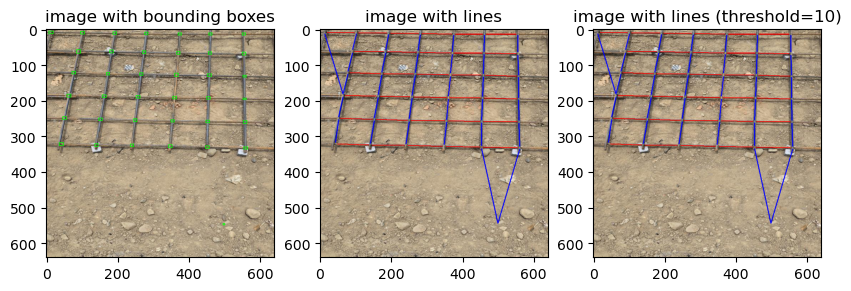

right
[     1.5533      1.5533     -1.5708      1.5533     -1.5533     -1.5708      1.5533     -1.5533     -1.5708     -1.5359     -1.5533     -1.5533     -1.5359]
min radian:  -0.017453292519943098
max radian:  0.03490658503988664
expanded min:  -0.10471975511965957
expanded max:  0.12217304763960311
[0, 1, 3, 5, 6, 7, 8, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 51, 52, 54, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 67, 68, 69, 70, 72, 73, 74, 76, 78, 80, 81, 83, 84, 85, 86, 88, 90, 91, 92, 93, 94, 95, 96, 98, 99, 102, 103, 105, 106, 107, 108, 109, 110, 113, 114, 115, 116, 117, 118, 121]
Detected lines (rho, theta):
Line: rho=470.00, theta=1.55
Line: rho=419.00, theta=1.55
Line: rho=-362.00, theta=-1.57
Line: rho=532.00, theta=1.55
Line: rho=-198.00, theta=-1.55
Line: rho=-279.00, theta=-1.57
Line: rho=324.00, theta=1.55
Line: rho=-166.00, theta=-1.55
Line: rho=-240.00, theta=-1.57
Line: rho=-1

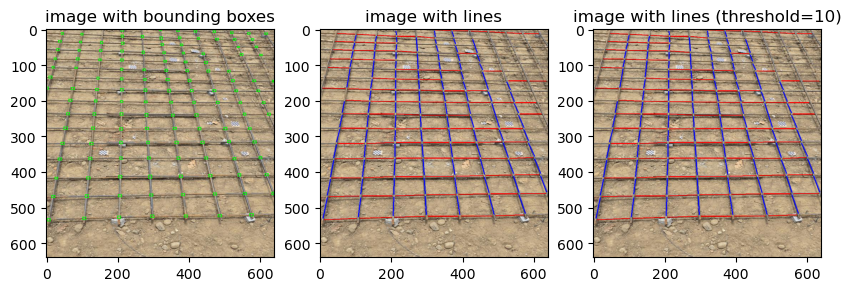

right
[     1.2043      1.2741      1.1694      1.2217      1.1345]
min radian:  2.705260340591211
max radian:  2.8448866807507573
expanded min:  2.6179938779914944
expanded max:  2.9321531433504737
[0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 41]
Detected lines (rho, theta):
Line: rho=424.00, theta=1.20
Line: rho=267.00, theta=1.27
Line: rho=520.00, theta=1.17
Line: rho=347.00, theta=1.22
Line: rho=631.00, theta=1.13
up
[   -0.34907    -0.38397    -0.10472    -0.22689    -0.27925    -0.17453   -0.034907    -0.50615]
min radian:  1.064650843716541
max radian:  1.53588974175501
expanded min:  0.9773843811168245
expanded max:  1.6231562043547263
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
Detected lines (rho, theta):
Line: rho=284.00, theta=-0.35
Line: rho=336.00, theta=-0.38
Line: rho=88.00, theta=-0

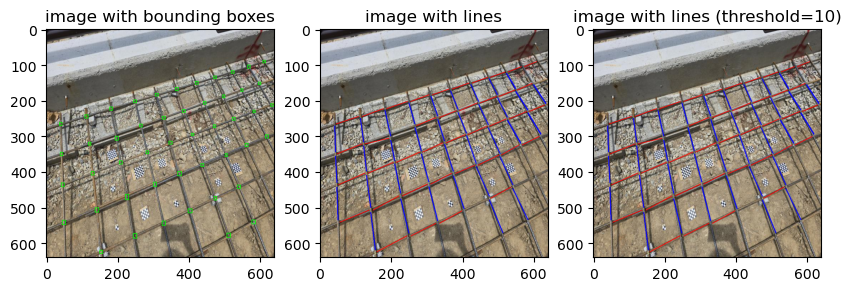

In [2]:
image_paths = [
    "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg",
    "data/intersect-detect/test/images/20250620_114830_jpg.rf.5e2332d4c667c38b39dfc6d6839eddf1.jpg",
    "data/intersect-detect/test/images/20250620_113200_jpg.rf.c129e547c74634bf1848bf9ef225a321.jpg",
]
model_path = "runs/detect/tune/weights/best.pt"


# Draw bounding boxes
def draw_bounding_boxes(image_path, model_path):
    image = Image.open(image_path)
    draw_boxes = ImageDraw.Draw(image)

    bounding_boxes = get_bounding_boxes(image, model_path)
    for box in bounding_boxes:
        draw_boxes.rectangle([box[0], box[1], box[2], box[3]], outline="lime", width=2)

    return image


# Draw lines
def draw_lines(image_path, model_path, threshold=10):
    image = Image.open(image_path).copy()
    draw_lines = ImageDraw.Draw(image)

    json_data = get_lines(image_path, model_path, threshold=threshold)
    data = json.loads(json_data)
    for shape in data["shapes"]:
        points = shape["points"]
        color = "red" if shape["orientation"] == "horizontal" else "blue"
        draw_lines.line([tuple(points[0]), tuple(points[1])], fill=color, width=3)

    return image


def show_result(image_path, model_path):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("image with bounding boxes")
    plt.imshow(draw_bounding_boxes(image_path, model_path))
    plt.subplot(1, 3, 2)
    plt.title("image with lines")
    plt.imshow(draw_lines(image_path, model_path, threshold=0))
    plt.subplot(1, 3, 3)
    plt.title("image with lines (threshold=10)")
    plt.imshow(draw_lines(image_path, model_path))
    plt.show()


for path in image_paths:
    show_result(path, model_path)
